In [188]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter


import importlib, functions.fitting_small as fitting_small
importlib.reload(fitting_small)

fs = fitting_small.fitting_smoothly

df = pd.read_csv('sync_data/1mHz_data.csv')


files = ['data_3/800mHz_data.csv',
         'data_3/810mHz_data.csv',
         'data_3/820mHz_data.csv',
         'data_3/830mHz_data.csv',
         'data_3/840mHz_data.csv',
         'data_3/850mHz_data.csv',
         'data_3/860mHz_data.csv',
         'data_3/870mHz_data.csv',
         'data_3/880mHz_data.csv',
         'data_3/890mHz_data.csv',
         'data_3/900mHz_data.csv'
         ]
frequencies_list = [0.800,0.810,0.820,0.830,0.840,0.850,0.860,0.870,0.880,0.890,0.900]  # in mHz
amplitudes = []
phases = []
frequencies = []

def sin_model(t, A, w, phi, C):
    return A*np.sin(w*t + phi) + C


Processing file: data_3/800mHz_data.csv
standart error B: 9.41728700232385e-06
standart error A: 9.417286957946086e-06
frequency of B: 0.8 Hz
phase of B: 0.7675416770247692
Estimated amplitude for B: 0.1708131830180402
frequency of A: 0.8 Hz
phase of A: 1.346955175078099
Estimated amplitude for A: 4.99982922850648


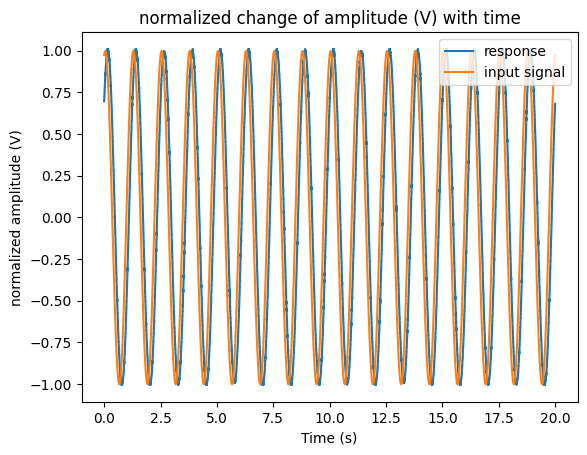

Processing file: data_3/810mHz_data.csv
standart error B: 9.431239835407656e-06
standart error A: 9.381552911964511e-06
frequency of B: 0.81 Hz
phase of B: 0.008236461894359226
Estimated amplitude for B: 0.1911684412108482
frequency of A: 0.81 Hz
phase of A: 0.663674462005473
Estimated amplitude for A: 4.999743637682026


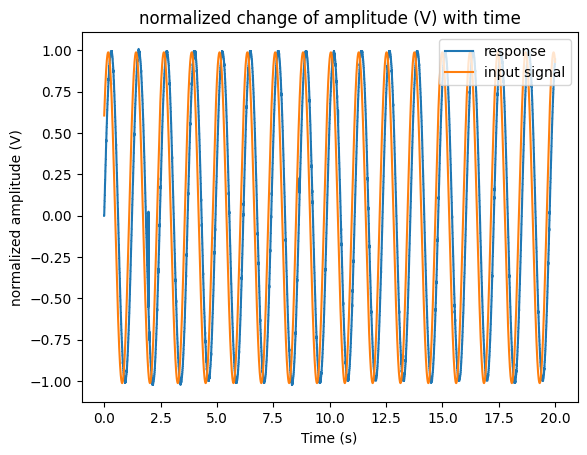

Processing file: data_3/820mHz_data.csv
standart error B: 9.438326326486397e-06
standart error A: 9.436540677531749e-06
frequency of B: 0.82 Hz
phase of B: 1.5373057103282317
Estimated amplitude for B: 0.21672132039056108
frequency of A: 0.82 Hz
phase of A: -0.8520024623269254
Estimated amplitude for A: -4.999894123059606


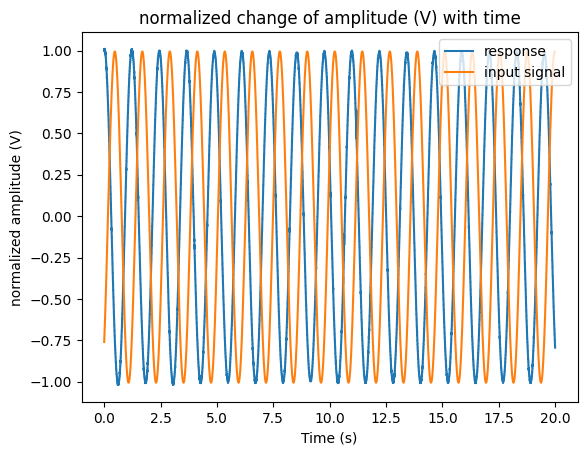

Processing file: data_3/830mHz_data.csv
standart error B: 9.397919542939871e-06
standart error A: 9.404602137115932e-06
frequency of B: 0.83 Hz
phase of B: 0.8976346036526411
Estimated amplitude for B: 0.24538312309745033
frequency of A: 0.83 Hz
phase of A: 1.7756256596831905
Estimated amplitude for A: 4.99990440508738


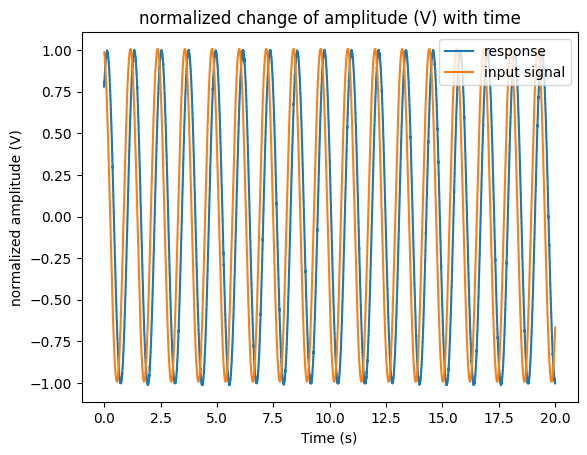

Processing file: data_3/840mHz_data.csv
standart error B: 9.377232523750063e-06
standart error A: 9.427249277707052e-06
frequency of B: 0.84 Hz
phase of B: 0.4749897945933342
Estimated amplitude for B: 0.27874095467609966
frequency of A: 0.84 Hz
phase of A: 1.5216177046634984
Estimated amplitude for A: 4.999858428204992


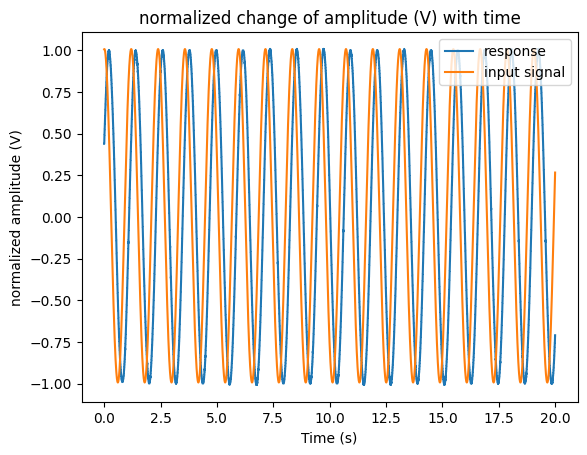

Processing file: data_3/850mHz_data.csv
standart error B: 9.417286971398645e-06
standart error A: 9.417286955613395e-06
frequency of B: 0.85 Hz
phase of B: 1.3537666864850726
Estimated amplitude for B: 0.3076431194175936
frequency of A: 0.85 Hz
phase of A: -0.5333966941888931
Estimated amplitude for A: -4.9998285715368125


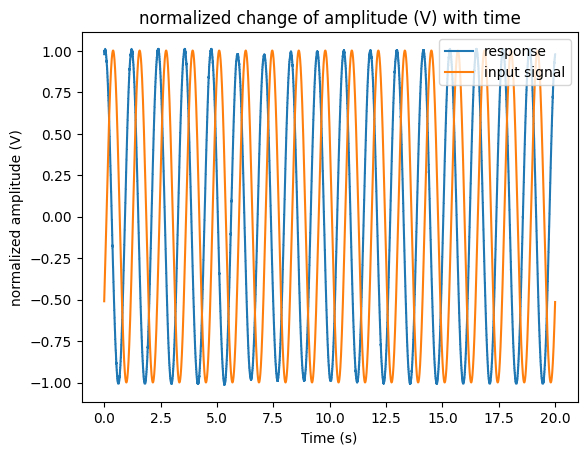

Processing file: data_3/860mHz_data.csv
standart error B: 9.443457504316933e-06
standart error A: 9.39702856288923e-06
frequency of B: 0.86 Hz
phase of B: -1.077566775785972
Estimated amplitude for B: -0.32802788262588334
frequency of A: 0.86 Hz
phase of A: 0.4315536894456116
Estimated amplitude for A: -4.999884312226797


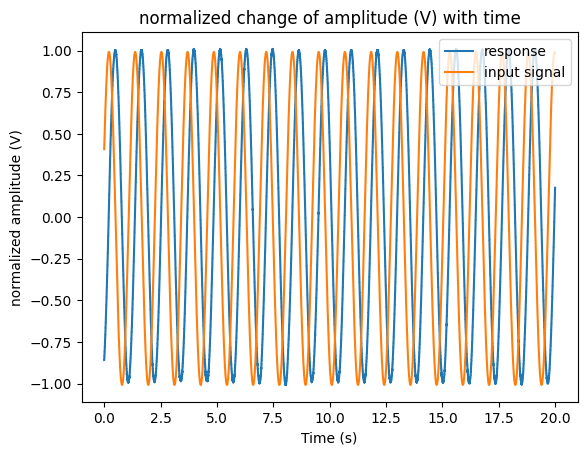

Processing file: data_3/870mHz_data.csv
standart error B: 9.438564430680539e-06
standart error A: 9.406006262159598e-06
frequency of B: 0.87 Hz
phase of B: -0.954811574096971
Estimated amplitude for B: 0.32169594744152097
frequency of A: 0.87 Hz
phase of A: 0.8192508539394765
Estimated amplitude for A: 4.999741699178929


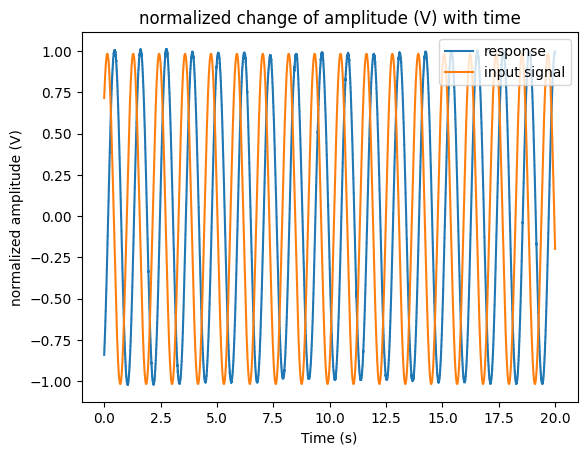

Processing file: data_3/880mHz_data.csv
standart error B: 9.443284394953638e-06
standart error A: 9.396080349942621e-06
frequency of B: 0.88 Hz
phase of B: -0.5044364087324573
Estimated amplitude for B: 0.3036431587615363
frequency of A: 0.88 Hz
phase of A: 1.5275957306627155
Estimated amplitude for A: 4.999870992911147


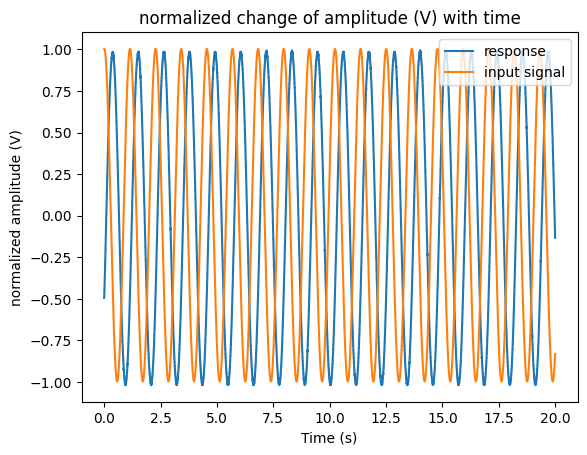

Processing file: data_3/890mHz_data.csv
standart error B: 9.38702869852208e-06
standart error A: 9.399540490164888e-06
frequency of B: 0.89 Hz
phase of B: 0.9802069731603192
Estimated amplitude for B: 0.2705759585759977
frequency of A: 0.89 Hz
phase of A: 0.08382546567053109
Estimated amplitude for A: -4.999816907817361


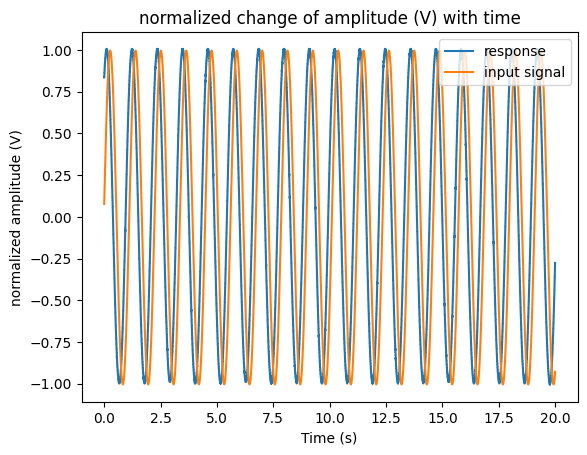

Processing file: data_3/900mHz_data.csv
standart error B: 9.417286933024839e-06
standart error A: 9.417287004009605e-06
frequency of B: 0.9 Hz
phase of B: -0.993829393638006
Estimated amplitude for B: 0.23568642241087273
frequency of A: 0.9 Hz
phase of A: 1.4112944940312853
Estimated amplitude for A: 4.999825318955606


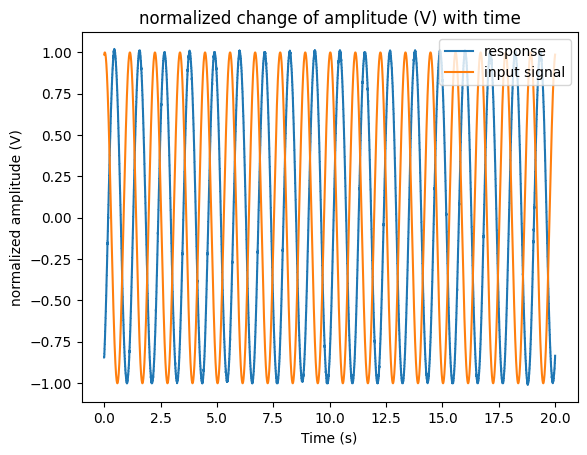

In [189]:
for file , freq in zip(files, frequencies_list):
    print("Processing file:", file)
    df = pd.read_csv(file)
    time = df['Time (s)'].to_numpy()
    voltage_A = df['Input A max (V)'].to_numpy() - np.mean(df['Input A max (V)'].to_numpy())
    voltage_B = df['Input B max (V)'].to_numpy() - np.mean(df['Input B max (V)'].to_numpy())
    
    amp_B, phase_B, stderr_B = fs(time, voltage_B, freq)
    amp_A, phase_A, stderr_A = fs(time, voltage_A, freq)

    print("standart error B: "+str(stderr_B))
    print("standart error A: "+str(stderr_A))
    
    amplitudes.append(amp_B)
    phases.append(phase_B)
    frequencies.append(freq)
    
    print('frequency of B:', freq, 'Hz')
    print('phase of B:', phase_B)
    print('Estimated amplitude for B:', amp_B)
    
    print('frequency of A:', freq, 'Hz')
    print('phase of A:', phase_A)
    print('Estimated amplitude for A:', amp_A)
    
    
    plt.plot(time, voltage_B/amp_B, label='response')
    plt.plot(time, voltage_A/amp_A, label='input signal')
    plt.xlabel('Time (s)')
    plt.ylabel('normalized amplitude (V)')
    plt.title('normalized change of amplitude (V) with time')
    plt.legend(loc='upper right')
    plt.show()


In [190]:
'''
for file in files:
    df = pd.read_csv(file)
    time = df['Time (s)'].to_numpy()
    voltage_in = df['Input A max (V)'].to_numpy() - np.mean(df['Input A max (V)'].to_numpy())
    voltage_out = df['Input B max (V)'].to_numpy() - np.mean(df['Input B max (V)'].to_numpy())
    num_bins = len(time)
    dt = time[1] - time[0]
    
    x_in = np.real(fft(voltage_in))
    x_out = np.real(fft(voltage_out))
    f = fftfreq(num_bins, dt)
    
    amp_in = 2 * (1/num_bins) * np.abs(x_in)
    amp_out = 2 * (1/num_bins) * np.abs(x_out)
    
    
    # Find the peak frequency in the input signal
    

    fr_in = f[np.argmax(amp_in)]
    print(f'Dominant frequency input: {fr_in} Hz')
    plt.plot(f, amp_in)
    plt.title('Fourier Transform input signal')
    plt.xlabel('Frequency (Hz)')
    plt.xlim(0,1.75)
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()
    
    fr_out = f[np.argmax(amp_out)]
    print(f'Dominant frequency output: {fr_out} Hz')
    plt.plot(f, amp_out)
    plt.title('Fourier Transform output signal')
    plt.xlabel('Frequency (Hz)')
    plt.xlim(0,1.75)
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()
'''

"\nfor file in files:\n    df = pd.read_csv(file)\n    time = df['Time (s)'].to_numpy()\n    voltage_in = df['Input A max (V)'].to_numpy() - np.mean(df['Input A max (V)'].to_numpy())\n    voltage_out = df['Input B max (V)'].to_numpy() - np.mean(df['Input B max (V)'].to_numpy())\n    num_bins = len(time)\n    dt = time[1] - time[0]\n\n    x_in = np.real(fft(voltage_in))\n    x_out = np.real(fft(voltage_out))\n    f = fftfreq(num_bins, dt)\n\n    amp_in = 2 * (1/num_bins) * np.abs(x_in)\n    amp_out = 2 * (1/num_bins) * np.abs(x_out)\n\n\n    # Find the peak frequency in the input signal\n\n\n    fr_in = f[np.argmax(amp_in)]\n    print(f'Dominant frequency input: {fr_in} Hz')\n    plt.plot(f, amp_in)\n    plt.title('Fourier Transform input signal')\n    plt.xlabel('Frequency (Hz)')\n    plt.xlim(0,1.75)\n    plt.ylabel('Amplitude')\n    plt.grid()\n    plt.show()\n\n    fr_out = f[np.argmax(amp_out)]\n    print(f'Dominant frequency output: {fr_out} Hz')\n    plt.plot(f, amp_out)\n    plt

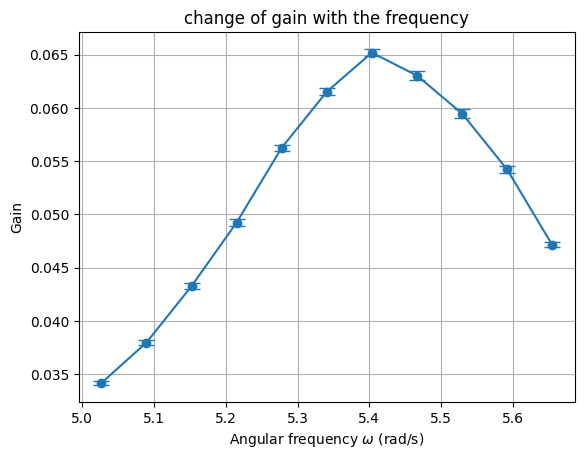

In [201]:
omegas = np.array(frequencies)*2*np.pi
gains = []
errsors = []
for file, freq in zip(files, frequencies_list):
    df = pd.read_csv(file)
    voltage_in = df['Input A max (V)'].to_numpy() - np.mean(df['Input A max (V)'].to_numpy())
    voltage_out = df['Input B max (V)'].to_numpy() - np.mean(df['Input B max (V)'].to_numpy())
    num_bins = len(voltage_in)
    
    v_in = np.fft.rfft(voltage_in)
    v_out = np.fft.rfft(voltage_out)    
    
    amp_in = 2 * (1/num_bins) * np.abs(v_in)
    amp_out = 2 * (1/num_bins) * np.abs(v_out)
    
    
    k = np.argmax(amp_in[1:]) + 1
    gain = amp_out[k] / amp_in[k]
    gains.append(gain)
    error = np.std(voltage_out)/np.sqrt(len(voltage_out))
    delta_p_err = error / amp_in
    errsors.append(delta_p_err[k])
    
plt.errorbar(omegas, gains, yerr=errsors, fmt='o-', capsize=6)
plt.xlabel(r"Angular frequency $\omega$ (rad/s)")
plt.ylabel(r"Gain")
plt.grid(True)
plt.title('change of gain with the frequency')
plt.show()
    

In [202]:
# Find the width of the gain peak using half-maximum method
gains_array = np.array(gains)
max_gain = np.max(gains_array)
half_max = max_gain / 2

# Find indices where gain crosses half maximum
above_half = gains_array >= half_max
# Find the edges of the peak
left_idx = np.argmax(above_half)
right_idx = len(above_half) - 1 - np.argmax(above_half[::-1])

# Interpolate to find more precise crossing points
omega_left = np.interp(half_max, gains_array[:left_idx+1], omegas[:left_idx+1])
omega_right = np.interp(half_max, gains_array[right_idx:][::-1], omegas[right_idx:][::-1])

# Calculate FWHM (Full Width at Half Maximum)
fwhm = omega_right - omega_left

print(f"Maximum gain: {max_gain:.4f}")
print(f"Half maximum: {half_max:.4f}")
print(f"Left crossing (ω): {omega_left:.4f} rad/s")
print(f"Right crossing (ω): {omega_right:.4f} rad/s")
print(f"FWHM (peak width): {fwhm:.4f} rad/s")
print(f"Resonance frequency (ω₀): {omegas[np.argmax(gains_array)]:.4f} rad/s")
print(f"Quality factor Q ≈ ω₀/Δω: {omegas[np.argmax(gains_array)] / fwhm:.2f}")

Maximum gain: 0.0652
Half maximum: 0.0326
Left crossing (ω): 5.0265 rad/s
Right crossing (ω): 5.6549 rad/s
FWHM (peak width): 0.6283 rad/s
Resonance frequency (ω₀): 5.4035 rad/s
Quality factor Q ≈ ω₀/Δω: 8.60


1.346955175078099 0.7675416770247692
raw phase diff: 0.18443304461870746
adjusted phase diff: 0.18443304461870746
0.663674462005473 0.008236461894359226
raw phase diff: 0.2086323952159
adjusted phase diff: 0.2086323952159
-0.8520024623269254 1.5373057103282317
raw phase diff: 0.2394595875041361
adjusted phase diff: 0.2394595875041361
1.7756256596831905 0.8976346036526411
raw phase diff: 0.27947323311547034
adjusted phase diff: 0.27947323311547034
1.5216177046634984 0.4749897945933342
raw phase diff: 0.3331520109312127
adjusted phase diff: 0.3331520109312127
-0.5333966941888931 1.3537666864850726
raw phase diff: 0.3992972390874523
adjusted phase diff: 0.3992972390874523
0.4315536894456116 -1.077566775785972
raw phase diff: 0.4803679635254946
adjusted phase diff: 0.4803679635254946
0.8192508539394765 -0.954811574096971
raw phase diff: 0.564701609551221
adjusted phase diff: 0.564701609551221
1.5275957306627155 -0.5044364087324573
raw phase diff: 0.6468159190126821
adjusted phase diff: 0.6

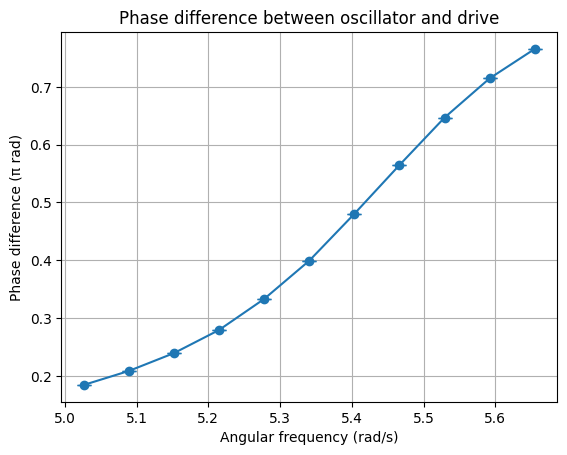

In [199]:
# Calculate phase difference (phase_B - phase_A from the fitting results)
# Since we only have phase_B stored in phases list, we need to recalculate
phase_differences = []
errsors = []
for file, freq in zip(files, frequencies_list):
    df = pd.read_csv(file)
    time = df['Time (s)'].to_numpy()
    voltage_A = df['Input A max (V)'].to_numpy() - np.mean(df['Input A max (V)'].to_numpy())
    voltage_B = df['Input B max (V)'].to_numpy() - np.mean(df['Input B max (V)'].to_numpy())
    
    amp_B, phase_B, stderr_B = fs(time, voltage_B, freq)
    amp_A, phase_A, stderr_A = fs(time, voltage_A, freq)

    error = np.sqrt(stderr_A**2 + stderr_B**2)
    errsors.append(error)

    print(phase_A, phase_B)
    
    phase_diff = phase_A - phase_B
    phase_diff = phase_diff/np.pi
    if phase_diff < 0:
        phase_diff += 1
    # phase difference in terms of pi
    print("raw phase diff:", phase_diff)
    print("adjusted phase diff:", phase_diff)

    phase_differences.append(phase_diff)

# Use frequencies from the loop (matching files length) instead of omegas
print("omegas:", omegas)
print("phase_differences:", phase_differences)
plt.errorbar(omegas, phase_differences, yerr=errsors, fmt='o-', capsize=5)
#plt.plot(omegas, phase_differences, 'o-')
plt.xlabel('Angular frequency (rad/s)')
plt.ylabel('Phase difference (π rad)')
plt.title('Phase difference between oscillator and drive')
plt.grid(True)
plt.show()